# Temporal Shift Module (TSM) 

In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path
from tqdm import tqdm
import random
import pandas as pd

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class TSM(nn.Module):
    def __init__(self, channels, fold_div):
        super().__init__()
        self.channels = channels
        self.fold_div = fold_div
    def forward(self, x):
        B, T, C, H, W = x.size()
        fold = self.channels // self.fold_div
        out = torch.zeros_like(x)
        out[:, :-1, :fold] = x[:, 1:, :fold]
        out[:, 1:, fold:2*fold] = x[:, :-1, fold:2*fold]
        out[:, :, 2*fold:] = x[:, :, 2*fold:]
        return out

In [ ]:
# visualize
x = torch.arange(4*8).view(1,4,8,1,1).float()

tsm = TSM(8, 4)
y = tsm(x)

print("Input")
print(x.squeeze())

print("After TSM")
print(y.squeeze())

Input
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.],
        [16., 17., 18., 19., 20., 21., 22., 23.],
        [24., 25., 26., 27., 28., 29., 30., 31.]])
After TSM
tensor([[ 8.,  9.,  0.,  0.,  4.,  5.,  6.,  7.],
        [16., 17.,  2.,  3., 12., 13., 14., 15.],
        [24., 25., 10., 11., 20., 21., 22., 23.],
        [ 0.,  0., 18., 19., 28., 29., 30., 31.]])


# ResnetTSM

In [ ]:
class ResNetTSM(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()

        self.tsm = TSM(512, 4) #initialize TSM with 512 channels and 4 time steps

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        # x: [B, T, C, H, W]
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        features = self.resnet(x) # [B*T, 512]
        features = features.view(B, T, 512)
        features = features.unsqueeze(-1).unsqueeze(-1) # [B, T, 512, 1, 1]
        features = self.tsm(features) # [B, T, 512, 1, 1]
        features = features.mean(dim=1) # temporal average pooling [B, 512, 1, 1]
        features = features.squeeze()
        out = self.classifier(features) # [B, num_classes]
        return out
        
    
    
    

In [ ]:
class TemporalShift(nn.Module):
    def __init__(self, n_segment=8, n_div=8, mode='bidirectional'):
        super(TemporalShift, self).__init__()
        self.n_segment = n_segment
        self.fold_div = n_div
        self.mode = mode
        
    def forward(self, x):
        # x shape: [B*T, C, H, W]
        nt, c, h, w = x.size()
        n_batch = nt // self.n_segment
        x = x.view(n_batch, self.n_segment, c, h, w)
        
        # Calculate how many channels to shift
        fold = c // self.fold_div
        
        if self.mode == 'bidirectional':
            # Split channels into 3 parts: forward shift, backward shift, no shift
            out = torch.zeros_like(x)
            
            # Forward shift (shift to future)
            out[:, :-1, :fold] = x[:, 1:, :fold]  # Shift from t+1 to t
            out[:, -1, :fold] = x[:, -1, :fold]   # Last frame stays
            
            # Backward shift (shift to past)
            out[:, 1:, fold:2*fold] = x[:, :-1, fold:2*fold]  # Shift from t-1 to t
            out[:, 0, fold:2*fold] = x[:, 0, fold:2*fold]     # First frame stays
            
            # No shift for remaining channels
            out[:, :, 2*fold:] = x[:, :, 2*fold:]
            
        elif self.mode == 'forward':
            out = torch.zeros_like(x)
            out[:, :-1, :fold] = x[:, 1:, :fold]
            out[:, -1, :fold] = x[:, -1, :fold]
            out[:, :, fold:] = x[:, :, fold:]
            
        elif self.mode == 'backward':
            out = torch.zeros_like(x)
            out[:, 1:, :fold] = x[:, :-1, :fold]
            out[:, 0, :fold] = x[:, 0, :fold]
            out[:, :, fold:] = x[:, :, fold:]
        
        return out.view(nt, c, h, w)
def make_temporal_shift(net, n_segment, n_div=8, mode='bidirectional'):
    """Insert TSM into a ResNet model"""
    
    def make_block_temporal(stage, n_segment):
        blocks = list(stage.children())
        for i, block in enumerate(blocks):
            # Insert TSM before the first conv in each residual block
            blocks[i].conv1 = nn.Sequential(
                TemporalShift(n_segment=n_segment, n_div=n_div, mode=mode),
                block.conv1
            )
        return nn.Sequential(*blocks)
    
    # Apply TSM to each residual stage
    net.layer1 = make_block_temporal(net.layer1, n_segment)
    net.layer2 = make_block_temporal(net.layer2, n_segment)
    net.layer3 = make_block_temporal(net.layer3, n_segment)
    net.layer4 = make_block_temporal(net.layer4, n_segment)


class TSMResNet(nn.Module):
    """ResNet-18 with Temporal Shift Module for video classification
    
    Args:
        num_classes: Number of action classes
        n_segment: Number of frames per video clip
        pretrained: Use ImageNet pretrained weights
    """
    def __init__(self, num_classes, n_segment=8, pretrained=True):
        super(TSMResNet, self).__init__()
        self.num_classes = num_classes
        self.n_segment = n_segment
        
        # Load ResNet-18 backbone
        resnet = models.resnet18(pretrained=pretrained)
        
        # Insert TSM into ResNet
        make_temporal_shift(resnet, n_segment=n_segment, n_div=8, mode='bidirectional')
        
        # Remove the original FC layer
        self.base_model = nn.Sequential(*list(resnet.children())[:-1])
        
        # New classifier
        self.fc = nn.Linear(512, num_classes)
        
        # Initialize the new FC layer
        nn.init.normal_(self.fc.weight, 0, 0.001)
        nn.init.constant_(self.fc.bias, 0)
        
    def forward(self, x):
        """
        Args:
            x: Input tensor of shape [B, T, C, H, W]
        Returns:
            Output logits of shape [B, num_classes]
        """
        batch_size, n_frames, c, h, w = x.size()
        
        # Reshape to [B*T, C, H, W] for 2D CNN processing
        x = x.view(batch_size * n_frames, c, h, w)
        
        # Extract features with TSM
        x = self.base_model(x)  # [B*T, 512, 1, 1]
        x = x.view(batch_size * n_frames, -1)  # [B*T, 512]
        
        # Reshape to [B, T, 512] and average over time
        x = x.view(batch_size, n_frames, -1)
        x = x.mean(dim=1)  # Temporal pooling: [B, 512]
        
        # Classification
        x = self.fc(x)  # [B, num_classes]
        
        return x

# Test the model
model = TSMResNet(num_classes=101, n_segment=8, pretrained=False)
test_input = torch.randn(2, 8, 3, 112, 112)  # [B=2, T=8, C=3, H=112, W=112]
output = model(test_input)
print(f"Model output shape: {output.shape}")
print(f"Expected: [batch_size=2, num_classes=101]")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Dataset Preparation

In [49]:
DATA_ROOT = Path("/home/multi-gpu/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4")
print("Dataset structure:")
for split in ['train', 'val', 'test']:
    split_dir = DATA_ROOT / split
    if split_dir.exists():
        num_classes = len([d for d in split_dir.iterdir() if d.is_dir()])
        print(f"  {split}: {num_classes} classes")
    else:
        print(f"  {split}: NOT FOUND")

Dataset structure:
  train: 101 classes
  val: 101 classes
  test: 101 classes


In [50]:
class UCF101Dataset(Dataset):
    def __init__(self, root_dir, n_frames=8, transform=None, mode='train', 
                 num_classes=None, selected_classes=None):
        self.root_dir = Path(root_dir)
        self.n_frames = n_frames
        self.transform = transform
        self.mode = mode
        
        # Find all video files and build class mapping
        self.video_files = []
        self.labels = []
        self.class_names = []
        
        # Look for the split directory (train, val, or test)
        split_dir = self.root_dir / mode
        
        if not split_dir.exists():
            raise ValueError(f"Split directory not found: {split_dir}")
        
        # Get all class directories
        all_class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
        all_class_names = sorted([d.name for d in all_class_dirs])
        
        # Filter classes if requested
        if selected_classes is not None:
            # Use specific classes provided
            self.class_names = [c for c in selected_classes if c in all_class_names]
            if len(self.class_names) != len(selected_classes):
                missing = set(selected_classes) - set(self.class_names)
                print(f"Warning: Some classes not found: {missing}")
        elif num_classes is not None:
            # Use first N classes
            self.class_names = all_class_names[:num_classes]
        else:
            # Use all classes
            self.class_names = all_class_names
        
        # Build class to index mapping
        class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
        
        # Collect videos only from selected classes
        for class_dir in all_class_dirs:
            class_name = class_dir.name
            
            # Skip if not in selected classes
            if class_name not in class_to_idx:
                continue
            
            class_idx = class_to_idx[class_name]
            
            # Find all video files
            videos = list(class_dir.glob('*.avi')) + list(class_dir.glob('*.mp4'))
            for video_path in videos:
                self.video_files.append(str(video_path))
                self.labels.append(class_idx)
        
        print(f"\n{'='*60}")
        print(f"UCF101 Dataset - {mode.upper()} mode")
        print(f"{'='*60}")
        print(f"Number of classes: {len(self.class_names)}")
        print(f"Classes: {', '.join(self.class_names[:5])}{'...' if len(self.class_names) > 5 else ''}")
        print(f"Number of videos: {len(self.video_files)}")
        print(f"Frames per video: {n_frames}")
        print(f"Split directory: {split_dir}")
        print(f"{'='*60}\n")
    
    def __len__(self):
        return len(self.video_files)
    
    def load_video(self, video_path):
        """Load video and sample n_frames uniformly"""
        cap = cv2.VideoCapture(video_path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if frame_count < self.n_frames:
            # If video has fewer frames, repeat last frame
            frame_indices = list(range(frame_count)) + [frame_count-1] * (self.n_frames - frame_count)
        else:
            # Sample frames uniformly
            frame_indices = np.linspace(0, frame_count - 1, self.n_frames, dtype=int)
        
        frames = []
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            else:
                # If frame read fails, use the last valid frame
                if frames:
                    frames.append(frames[-1])
        
        cap.release()
        return frames
    
    def __getitem__(self, idx):
        video_path = self.video_files[idx]
        label = self.labels[idx]
        
        # Load video frames
        frames = self.load_video(video_path)
        
        # Apply transforms to each frame
        if self.transform:
            frames = [self.transform(frame) for frame in frames]
        
        # Stack frames: [T, C, H, W]
        frames = torch.stack(frames)
        
        return frames, label

In [51]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 171)),  # Resize to standard size
    transforms.RandomCrop(112),      # Random crop for augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 171)),
    transforms.CenterCrop(112),      # Center crop for testing
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

NUM_CLASSES = 10 
SELECTED_CLASSES = None
print("Loading UCF101 dataset...")
print(f"Configuration: Using {NUM_CLASSES if NUM_CLASSES else 'ALL'} classes\n")

train_dataset = UCF101Dataset(
    root_dir=DATA_ROOT,
    n_frames=8,
    transform=train_transform,
    mode='train',
    num_classes=NUM_CLASSES,
    selected_classes=SELECTED_CLASSES
)

val_dataset = UCF101Dataset(
    root_dir=DATA_ROOT,
    n_frames=8,
    transform=test_transform,
    mode='val',
    num_classes=NUM_CLASSES,
    selected_classes=SELECTED_CLASSES
)

test_dataset = UCF101Dataset(
    root_dir=DATA_ROOT,
    n_frames=8,
    transform=test_transform,
    mode='test',
    num_classes=NUM_CLASSES,
    selected_classes=SELECTED_CLASSES
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"\nData loaders created successfully!")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Loading UCF101 dataset...
Configuration: Using 10 classes


UCF101 Dataset - TRAIN mode
Number of classes: 10
Classes: ApplyEyeMakeup, ApplyLipstick, Archery, BabyCrawling, BalanceBeam...
Number of videos: 1125
Frames per video: 8
Split directory: /home/multi-gpu/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/train


UCF101 Dataset - VAL mode
Number of classes: 10
Classes: ApplyEyeMakeup, ApplyLipstick, Archery, BabyCrawling, BalanceBeam...
Number of videos: 186
Frames per video: 8
Split directory: /home/multi-gpu/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/val


UCF101 Dataset - TEST mode
Number of classes: 10
Classes: ApplyEyeMakeup, ApplyLipstick, Archery, BabyCrawling, BalanceBeam...
Number of videos: 194
Frames per video: 8
Split directory: /home/multi-gpu/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/test


Data loaders created successfully!
Train batches: 141
Val batches: 24
Test batche

# Training 

In [53]:
# Initialize model
num_classes = len(train_dataset.class_names)
model = TSMResNet(num_classes=num_classes, n_segment=8, pretrained=True)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"\n{'='*60}")
print("Training Configuration")
print(f"{'='*60}")
print(f"Model: TSM-ResNet18")
print(f"Number of classes: {num_classes}")
print(f"Device: {device}")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Loss: CrossEntropyLoss")
print(f"Batch size: 8")
print(f"{'='*60}\n")


Training Configuration
Model: TSM-ResNet18
Number of classes: 10
Device: cuda
Optimizer: Adam (lr=0.001)
Loss: CrossEntropyLoss
Batch size: 8



In [54]:
def train_epoch(model, train_loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]")
    for batch_idx, (frames, labels) in enumerate(pbar):
        # frames: [B, T, C, H, W], labels: [B]
        frames = frames.to(device)
        labels = labels.to(device)
        
        #forward pass
        optimizer.zero_grad()
        outputs = model(frames)
        loss = criterion(outputs, labels)
        
        #backward pass
        loss.backward()
        optimizer.step()
        
        #statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        #update progress bar
        pbar.set_postfix({
            'loss': running_loss / (batch_idx + 1),
            'acc': 100. * correct / total
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device, split='Val'):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for frames, labels in tqdm(test_loader, desc=f"[{split}]"):
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100. * correct / total
    return test_loss, test_acc

In [ ]:
num_epochs = 50
best_val_acc = 0.0
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("\n" + "="*60)
print("Starting Training")
print("="*60 + "\n")

for epoch in range(1, num_epochs + 1):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, epoch)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, split='Val')
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # Update learning rate
    scheduler.step()
    
    # Print epoch summary
    print(f"\nEpoch {epoch}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'class_names': train_dataset.class_names
        }, '/home/multi-gpu/ai_res/Khadija/best_tsm_model.pth')
        print(f"Saved best model (val acc: {best_val_acc:.2f}%)")
    print("-" * 60)

print("\n" + "="*60)
print(f"Training Complete! Best Validation Accuracy: {best_val_acc:.2f}%")
print("="*60 + "\n")

# Evaluate

In [55]:
# Load best model and evaluate on test set
checkpoint = torch.load('/home/multi-gpu/ai_res/Khadija/best_tsm_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

print("\n Evaluating on Test Set...")
test_loss, test_acc = evaluate(model, test_loader, criterion, device, split='Test')

print(f"\n{'='*60}")
print("Final Test Results")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
# print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print(f"{'='*60}\n")


 Evaluating on Test Set...


[Test]:   0%|          | 0/25 [00:00<?, ?it/s]

[Test]: 100%|██████████| 25/25 [00:04<00:00,  6.15it/s]


Final Test Results
Test Loss: 0.1957
Test Accuracy: 86.60%



# Visualize Training Progress

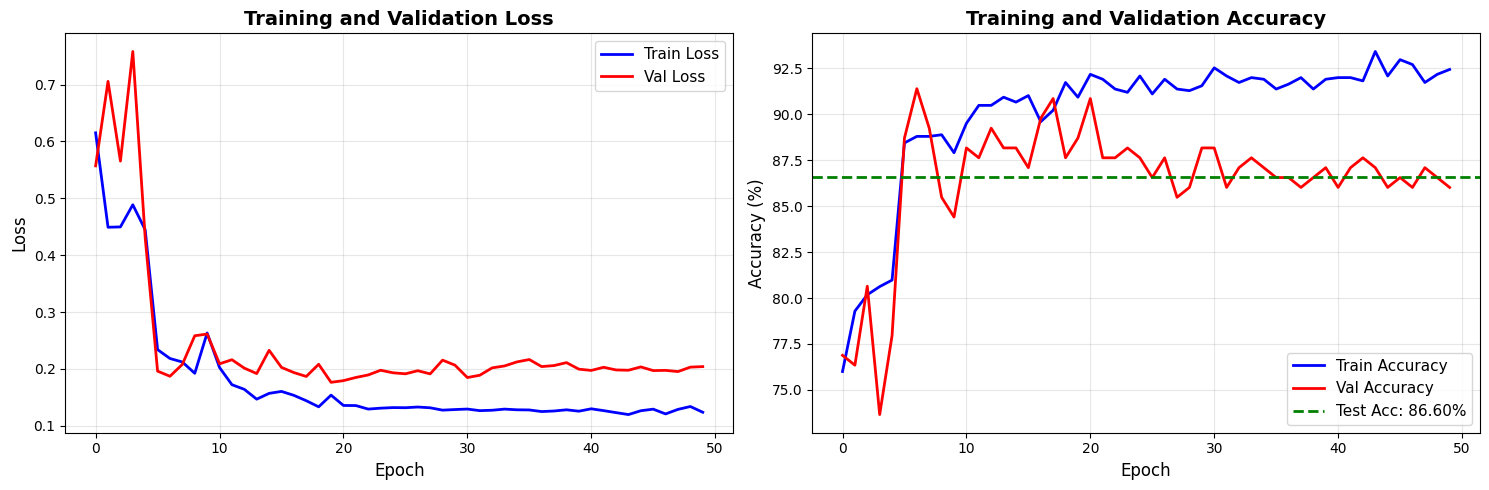


📈 Final Results:
  Best Val Accuracy: 91.40%
  Test Accuracy: 86.60%
  Final Train Accuracy: 92.44%


In [19]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(train_losses, 'b-', label='Train Loss', linewidth=2)
axes[0].plot(val_losses, 'r-', label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, 'b-', label='Train Accuracy', linewidth=2)
axes[1].plot(val_accs, 'r-', label='Val Accuracy', linewidth=2)
axes[1].axhline(y=test_acc, color='g', linestyle='--', label=f'Test Acc: {test_acc:.2f}%', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/home/multi-gpu/ai_res/Khadija/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📈 Final Results:")
print(f"  Best Val Accuracy: {best_val_acc:.2f}%")
print(f"  Test Accuracy: {test_acc:.2f}%")
print(f"  Final Train Accuracy: {train_accs[-1]:.2f}%")

# Inference

In [57]:
checkpoint = torch.load('/home/multi-gpu/ai_res/Khadija/best_tsm_model.pth')

def predict_video(model, video_path, class_names, n_frames=8, device='cuda'):
    model.eval()
    
    # Load video
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if frame_count < n_frames:
        frame_indices = list(range(frame_count)) + [frame_count-1] * (n_frames - frame_count)
    else:
        frame_indices = np.linspace(0, frame_count - 1, n_frames, dtype=int)
    
    frames = []
    display_frames = []  # For visualization
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            display_frames.append(frame_rgb)
            
            # Apply transform
            frame_tensor = test_transform(frame_rgb)
            frames.append(frame_tensor)
    
    cap.release()
    
    # Stack and add batch dimension
    video_tensor = torch.stack(frames).unsqueeze(0)  # [1, T, C, H, W]
    video_tensor = video_tensor.to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(video_tensor)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted_class = probabilities.max(1)
    
    predicted_class = predicted_class.item()
    confidence = confidence.item()
    
    # Get top-5 predictions
    top5_prob, top5_idx = probabilities[0].topk(min(5, len(class_names)))
    top5_classes = [class_names[idx] for idx in top5_idx.cpu().numpy()]
    top5_probs = top5_prob.cpu().numpy()
    
    return predicted_class, confidence, top5_classes, top5_probs, display_frames


# Get class names
class_names = checkpoint['class_names']

# Select random test videos from different classes
num_samples = 5
sample_indices = random.sample(range(len(test_dataset)), min(num_samples, len(test_dataset)))

results = []
for idx in sample_indices:
    video_path = test_dataset.video_files[idx]
    true_label = test_dataset.labels[idx]
    
    print(f"\n🎬 Video: {os.path.basename(video_path)}")
    print(f"True class: {class_names[true_label]}")
    
    predicted_class, confidence, top5_classes, top5_probs, display_frames = predict_video(
        model, video_path, class_names, n_frames=8, device=device
    )
    
    print(f"Predicted: {class_names[predicted_class]} ({confidence*100:.2f}%)")
    print(f"Correct: {'✅' if predicted_class == true_label else '❌'}")
    
    results.append({
        'video_path': video_path,
        'true_label': true_label,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'top5_classes': top5_classes,
        'top5_probs': top5_probs,
        'frames': display_frames
    })


🎬 Video: v_BabyCrawling_g09_c03.avi
True class: BabyCrawling
Predicted: BabyCrawling (99.99%)
Correct: ✅

🎬 Video: v_BabyCrawling_g13_c06.avi
True class: BabyCrawling
Predicted: BabyCrawling (58.82%)
Correct: ✅

🎬 Video: v_Archery_g11_c01.avi
True class: Archery
Predicted: Archery (71.04%)
Correct: ✅

🎬 Video: v_BenchPress_g04_c04.avi
True class: BenchPress
Predicted: BenchPress (99.95%)
Correct: ✅

🎬 Video: v_ApplyLipstick_g06_c05.avi
True class: ApplyLipstick
Predicted: ApplyLipstick (100.00%)
Correct: ✅


/tmp/ipykernel_867830/3751274592.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/home/multi-gpu/ai_res/Khadija/inference_result.png', dpi=150, bbox_inches='tight')
/home/multi-gpu/anaconda3/envs/resnettsm/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


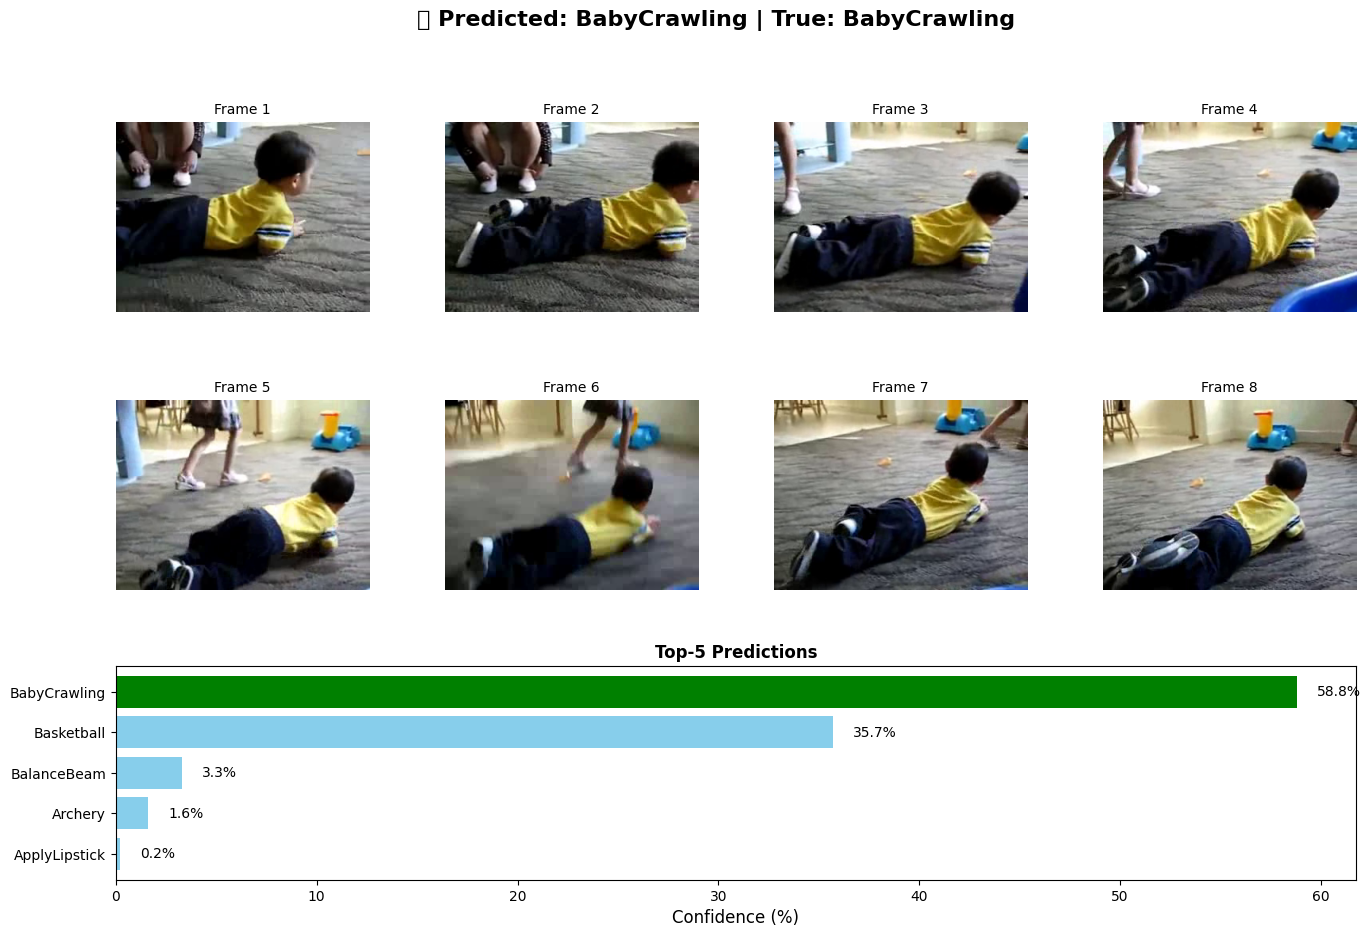

In [24]:
# Visualize predictions for the first sample
if results:
    sample = results[1]
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
    
    # Display frames
    for i, frame in enumerate(sample['frames']):
        if i < 8:
            row = i // 4
            col = i % 4
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(frame)
            ax.set_title(f"Frame {i+1}", fontsize=10)
            ax.axis('off')
    
    # Add prediction bar chart
    ax_bar = fig.add_subplot(gs[2, :])
    y_pos = np.arange(len(sample['top5_classes']))
    colors = ['green' if i == 0 else 'skyblue' for i in range(len(sample['top5_classes']))]
    ax_bar.barh(y_pos, sample['top5_probs'] * 100, color=colors)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(sample['top5_classes'])
    ax_bar.set_xlabel('Confidence (%)', fontsize=12)
    ax_bar.set_title('Top-5 Predictions', fontsize=12, fontweight='bold')
    ax_bar.invert_yaxis()
    
    # Add percentage labels
    for i, v in enumerate(sample['top5_probs'] * 100):
        ax_bar.text(v + 1, i, f'{v:.1f}%', va='center')
    
    # Add overall title
    correct = "✅" if sample['predicted_class'] == sample['true_label'] else "❌"
    fig.suptitle(
        f"{correct} Predicted: {class_names[sample['predicted_class']]} | True: {class_names[sample['true_label']]}",
        fontsize=16,
        fontweight='bold'
    )
    
    plt.savefig('/home/multi-gpu/ai_res/Khadija/inference_result.png', dpi=150, bbox_inches='tight')
    plt.show()

In [37]:
import cv2

if results:
    sample = results[1]

    frames = sample['frames']
    pred = class_names[sample['predicted_class']]
    true = class_names[sample['true_label']]

    h, w = frames[0].shape[:2]

    out_path = "/home/multi-gpu/ai_res/Khadija/inference_video.mp4"
    writer = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        6,
        (w, h + 80)   # extra space for text
    )

    for frame in frames:
        canvas = np.ones((h + 80, w, 3), dtype=np.uint8) * 255
        canvas[:h] = frame

        text1 = f"Predicted: {pred}"
        text2 = f"True: {true}"

        cv2.putText(canvas, text1, (20, h + 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)

        cv2.putText(canvas, text2, (20, h + 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,0,0), 2)

        writer.write(cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))

    writer.release()

    from IPython.display import Video
    Video(out_path)
